In [1]:
# Cell 1: Python package installations
# Run this cell once, then restart session before running the rest
%pip install numpy scipy scikit-learn ipywidgets matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cell 2: Python libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
    r2_score, accuracy_score, f1_score, fbeta_score, classification_report)
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact
import ipywidgets as widgets
import warnings
warnings.filterwarnings("ignore")
try:
    from IPython.display import display
except ImportError:
    display = print

In [3]:
# Cell 3: Load data
import os

data = None

local_path = "housing.csv"
if os.path.exists(local_path):
    data = pd.read_csv(local_path)
    print("Loaded local housing.csv")

if data is None:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        file_path = "/content/drive/MyDrive/Special Project/housing.csv"
        data = pd.read_csv(file_path)
        print("Loaded from Google Drive")
    except Exception:
        pass

if data is None:
    raise FileNotFoundError(
        "housing.csv not found. Download from: "
        "https://www.kaggle.com/datasets/camnugent/california-housing-prices"
    )

print("COLUMNS:", data.columns.tolist())
print("Shape:", data.shape)
display(data.head(3))

Loaded local housing.csv
COLUMNS: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']
Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


In [4]:
# Cell 4: Continuous Data Profiler
class ContinuousDataProfiler:
    def __init__(self, data):
        self.data = data.copy()
        self.history = []
        self.current_profile = None

    def update_data(self, new_data):
        self.history.append(self.data.copy())
        self.data = new_data.copy()
        self.generate_profile()

    def generate_profile(self):
        profile = {}
        num_cols = self.data.select_dtypes(include=["number"]).columns
        profile["shape"] = self.data.shape
        profile["dtypes"] = self.data.dtypes.astype(str).to_dict()
        profile["missing"] = self.data.isnull().sum().to_dict()
        profile["describe"] = self.data[num_cols].describe().to_dict() if len(num_cols) else {}
        self.current_profile = profile
        return profile

    def show_profile(self):
        if self.current_profile is None:
            self.generate_profile()
        p = self.current_profile
        print(f"Shape: {p['shape']}")
        print(f"Missing values: {sum(p['missing'].values())}")
        display(self.data.head(5))
        display(self.data.describe())
        return p

    def track_changes(self):
        if len(self.history) == 0:
            print("No previous version to compare with")
            return None
        old_data = self.history[-1]
        changes = {}
        added_cols = set(self.data.columns) - set(old_data.columns)
        removed_cols = set(old_data.columns) - set(self.data.columns)
        if added_cols:
            changes["added_columns"] = list(added_cols)
        if removed_cols:
            changes["removed_columns"] = list(removed_cols)
        common_cols = set(self.data.columns) & set(old_data.columns)
        statistical_changes = {}
        for col in common_cols:
            old_stats = old_data[col].describe()
            new_stats = self.data[col].describe()
            diff = (new_stats - old_stats).abs()
            significant_changes = diff[diff > 0.1 * old_stats.abs()]
            if not significant_changes.empty:
                statistical_changes[col] = significant_changes.to_dict()
        if statistical_changes:
            changes["statistical_changes"] = statistical_changes
        return changes

    def visualize_distributions(self, columns=None):
        if columns is None:
            columns = self.data.select_dtypes(include=["float64", "int64"]).columns
        plt.figure(figsize=(15, 10))
        for i, col in enumerate(columns[:9]):
            plt.subplot(3, 3, i + 1)
            sns.histplot(self.data[col], kde=True)
            plt.title(f"Distribution of {col}")
        plt.tight_layout()
        plt.show()

    def visualize_correlations(self):
        plt.figure(figsize=(10, 8))
        corr = self.data.select_dtypes(include="number").corr()
        sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
        plt.title("Feature Correlation Matrix")
        plt.show()

profiler = ContinuousDataProfiler(data)
print("Initial Data Profile:")
profiler.show_profile()

Initial Data Profile:
Shape: (20640, 10)
Missing values: 207


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


{'shape': (20640, 10),
 'dtypes': {'longitude': 'float64',
  'latitude': 'float64',
  'housing_median_age': 'float64',
  'total_rooms': 'float64',
  'total_bedrooms': 'float64',
  'population': 'float64',
  'households': 'float64',
  'median_income': 'float64',
  'median_house_value': 'float64',
  'ocean_proximity': 'object'},
 'missing': {'longitude': 0,
  'latitude': 0,
  'housing_median_age': 0,
  'total_rooms': 0,
  'total_bedrooms': 207,
  'population': 0,
  'households': 0,
  'median_income': 0,
  'median_house_value': 0,
  'ocean_proximity': 0},
 'describe': {'longitude': {'count': 20640.0,
   'mean': -119.56970445736432,
   'std': 2.0035317235025882,
   'min': -124.35,
   '25%': -121.8,
   '50%': -118.49,
   '75%': -118.01,
   'max': -114.31},
  'latitude': {'count': 20640.0,
   'mean': 35.63186143410853,
   'std': 2.1359523974571153,
   'min': 32.54,
   '25%': 33.93,
   '50%': 34.26,
   '75%': 37.71,
   'max': 41.95},
  'housing_median_age': {'count': 20640.0,
   'mean': 28.63

In [5]:
# Cell 5: Preprocessing
def preprocess_data(raw_data, target_col="median_house_value"):
    df = raw_data.copy()
    target = df[target_col] if target_col in df.columns else None
    feature_cols = [c for c in df.select_dtypes(include=["number"]).columns
                    if c != target_col]
    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
    df[feature_cols] = (df[feature_cols] - df[feature_cols].mean()) / df[feature_cols].std()
    if target is not None:
        df[target_col] = target
    print("Preprocessing complete. Columns:", df.columns.tolist())
    return df

processed_data = preprocess_data(data)
display(processed_data.head(2))

Preprocessing complete. Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-1.327803,1.052523,0.982119,-0.804800,-0.972453,-0.974405,-0.977009,2.344709,452600.0,NEAR BAY
1,-1.322812,1.043159,-0.607004,2.045841,1.357111,0.861418,1.669921,2.332181,358500.0,NEAR BAY


In [6]:
# Cell 6: Feature Engineering
def feature_engineering(df):
    try:
        if "total_rooms" in df.columns and "households" in df.columns:
            df["RoomsPerHousehold"] = df["total_rooms"] / df["households"].replace(0, np.nan)
        if "total_bedrooms" in df.columns and "total_rooms" in df.columns:
            df["BedroomsPerRoom"] = df["total_bedrooms"] / df["total_rooms"].replace(0, np.nan)
        if "population" in df.columns and "households" in df.columns:
            df["PopulationPerHousehold"] = df["population"] / df["households"].replace(0, np.nan)
        print("Feature engineering successful")
    except Exception as e:
        print(f"Feature engineering partially failed: {e}")
    return df

engineered_data = feature_engineering(processed_data)
print("\nEngineered columns:", engineered_data.columns.tolist())
display(engineered_data.head(2))

Feature engineering successful

Engineered columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity', 'RoomsPerHousehold', 'BedroomsPerRoom', 'PopulationPerHousehold']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,RoomsPerHousehold,BedroomsPerRoom,PopulationPerHousehold
0,-1.327803,1.052523,0.982119,-0.804800,-0.972453,-0.974405,-0.977009,2.344709,452600.0,NEAR BAY,0.823738,1.208317,0.997335
1,-1.322812,1.043159,-0.607004,2.045841,1.357111,0.861418,1.669921,2.332181,358500.0,NEAR BAY,1.225112,0.663351,0.515844


In [7]:
# Debug: Check Data Flow
print("=== DATA DEBUG ===")
print(f"Original: {data.shape}")
print(f"Processed: {processed_data.shape}")
print(f"Engineered: {engineered_data.shape}")

=== DATA DEBUG ===
Original: (20640, 10)
Processed: (20640, 13)
Engineered: (20640, 13)


RMSE: $49,486
R-squared: 0.8131


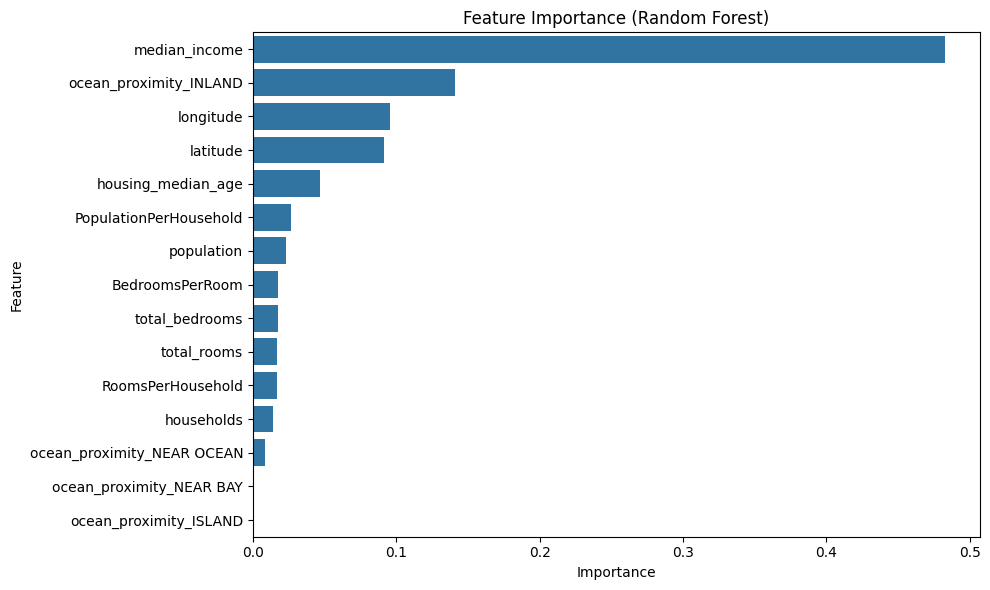

In [8]:
# Cell 7: Random Forest Regression
target_column = "median_house_value"

if target_column in engineered_data.columns:
    X = engineered_data.drop(columns=[target_column, "MedHouseVal"], errors="ignore")
    y = engineered_data[target_column]

    X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    cat_cols = X_train_rf.select_dtypes(include=["object", "category"]).columns
    if len(cat_cols) > 0:
        X_train_rf = pd.get_dummies(X_train_rf, columns=cat_cols, drop_first=True)
        X_test_rf = pd.get_dummies(X_test_rf, columns=cat_cols, drop_first=True)
        X_test_rf = X_test_rf.reindex(columns=X_train_rf.columns, fill_value=0)

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train_rf, y_train_rf)

    y_pred_rf = model.predict(X_test_rf)
    mse = mean_squared_error(y_test_rf, y_pred_rf)
    r2 = r2_score(y_test_rf, y_pred_rf)
    print(f"RMSE: ${np.sqrt(mse):,.0f}")
    print(f"R-squared: {r2:.4f}")

    feature_importance = pd.DataFrame({
        "Feature": X_train_rf.columns,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=feature_importance)
    plt.title("Feature Importance (Random Forest)")
    plt.tight_layout()
    plt.show()
else:
    print(f"Target {target_column} not found.")

In [9]:
# Cell 8: Model Monitoring
class ModelMonitor:
    def __init__(self, model, X_val, y_val):
        self.model = model
        self.baseline_X = X_val.copy()
        self.baseline_y = y_val.copy()
        self.performance_history = []

    def check_data_drift(self, new_X):
        drift_report = {}
        for col in new_X.columns:
            ks_stat, p_value = ks_2samp(self.baseline_X[col], new_X[col])
            drift_report[col] = {
                "ks_statistic": ks_stat,
                "p_value": p_value,
                "drift_detected": p_value < 0.05
            }
        return drift_report

    def check_concept_drift(self, new_X, new_y):
        baseline_pred = self.model.predict(self.baseline_X)
        baseline_score = r2_score(self.baseline_y, baseline_pred)
        new_pred = self.model.predict(new_X)
        new_score = r2_score(new_y, new_pred)
        score_diff = baseline_score - new_score
        return {
            "baseline_r2": baseline_score,
            "current_r2": new_score,
            "difference": score_diff,
            "drift_detected": abs(score_diff) > 0.1
        }

    def log_performance(self, X, y, dataset_name):
        pred = self.model.predict(X)
        mse = mean_squared_error(y, pred)
        r2 = r2_score(y, pred)
        self.performance_history.append({
            "dataset": dataset_name,
            "timestamp": pd.Timestamp.now(),
            "mse": mse,
            "r2": r2
        })
        return {"mse": mse, "r2": r2}

if "model" in locals() and "X_test_rf" in locals() and "y_test_rf" in locals():
    monitor = ModelMonitor(model, X_test_rf, y_test_rf)

    print("Data Drift Check (test vs itself - no drift expected):")
    data_drift = monitor.check_data_drift(X_test_rf)
    drifted = [c for c, r in data_drift.items() if r["drift_detected"]]
    print(f"  Features with drift detected: {len(drifted)}/{len(data_drift)}")

    print("\nConcept Drift Check:")
    cd = monitor.check_concept_drift(X_test_rf, y_test_rf)
    print(f"  Baseline R-squared: {cd[chr(98)+chr(97)+chr(115)+chr(101)+chr(108)+chr(105)+chr(110)+chr(101)+chr(95)+chr(114)+chr(50)]:.4f}")
    print(f"  Current R-squared:  {cd[chr(99)+chr(117)+chr(114)+chr(114)+chr(101)+chr(110)+chr(116)+chr(95)+chr(114)+chr(50)]:.4f}")
    print(f"  Drift:              {cd[chr(100)+chr(114)+chr(105)+chr(102)+chr(116)+chr(95)+chr(100)+chr(101)+chr(116)+chr(101)+chr(99)+chr(116)+chr(101)+chr(100)]}")
else:
    print("Model not trained - skipping monitoring setup")

Data Drift Check (test vs itself - no drift expected):
  Features with drift detected: 0/15

Concept Drift Check:
  Baseline R-squared: 0.8131
  Current R-squared:  0.8131
  Drift:              False


In [10]:
# Cell 9: Classification
def categorize_price(price):
    if price < 150000:
        return "Low"
    elif price < 300000:
        return "Medium"
    else:
        return "High"

df_class = data.copy()
df_class['price_category'] = df_class['median_house_value'].apply(categorize_price)
df_class = df_class.drop(columns=['median_house_value'])

X = df_class.drop(columns=['price_category'])
y = df_class['price_category']

num_cols = X.select_dtypes(include=np.number).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cat_cols = X_train_cls.select_dtypes(include=["object", "category"]).columns
if len(cat_cols) > 0:
    X_train_cls = pd.get_dummies(X_train_cls, columns=cat_cols, drop_first=True)
    X_test_cls = pd.get_dummies(X_test_cls, columns=cat_cols, drop_first=True)
    X_test_cls = X_test_cls.reindex(columns=X_train_cls.columns, fill_value=0)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_cls, y_train_cls)

y_pred_cls = clf.predict(X_test_cls)
acc = accuracy_score(y_test_cls, y_pred_cls)
f1 = f1_score(y_test_cls, y_pred_cls, average="macro")
f2 = fbeta_score(y_test_cls, y_pred_cls, beta=2, average="macro")

print("=== Classification Metrics ===")
print(f"Accuracy: {acc:.2f}")
print(f"F1 Score:  {f1:.2f}")
print(f"F2 Score:  {f2:.2f}")
print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_cls))

=== Classification Metrics ===
Accuracy: 0.83
F1 Score:  0.82
F2 Score:  0.81

Classification Report:
              precision    recall  f1-score   support

        High       0.86      0.72      0.78       758
         Low       0.86      0.87      0.86      1500
      Medium       0.80      0.84      0.82      1870

    accuracy                           0.83      4128
   macro avg       0.84      0.81      0.82      4128
weighted avg       0.83      0.83      0.83      4128



In [11]:
# Cell 10: Linear Regression
target = 'median_house_value'
features = data.drop(columns=[target])

num_cols = features.select_dtypes(include=np.number).columns
features[num_cols] = features[num_cols].fillna(features[num_cols].median())

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    features, data[target], test_size=0.2, random_state=42
)

cat_cols = X_train_lr.select_dtypes(include=["object", "category"]).columns
if len(cat_cols) > 0:
    X_train_lr = pd.get_dummies(X_train_lr, columns=cat_cols, drop_first=True)
    X_test_lr = pd.get_dummies(X_test_lr, columns=cat_cols, drop_first=True)
    X_test_lr = X_test_lr.reindex(columns=X_train_lr.columns, fill_value=0)

lr = LinearRegression()
lr.fit(X_train_lr, y_train_lr)

y_pred_lr = lr.predict(X_test_lr)
rmse = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
mae = mean_absolute_error(y_test_lr, y_pred_lr)
r2 = r2_score(y_test_lr, y_pred_lr)

print("=== Linear Regression Metrics ===")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE:  ${mae:,.0f}")
print(f"R-squared:   {r2:.4f}")

=== Linear Regression Metrics ===
RMSE: $70,061
MAE:  $50,671
R-squared:   0.6254


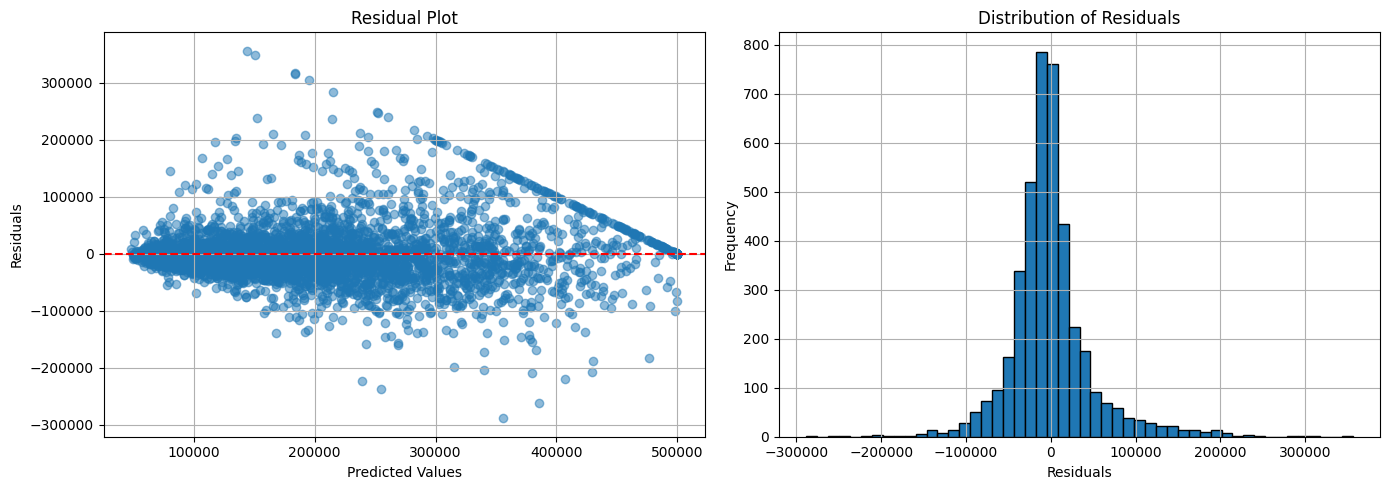

In [12]:
# Cell 11: Residual Analysis
if "model" in locals() and "X_test_rf" in locals() and "y_test_rf" in locals():
    y_pred_resid = model.predict(X_test_rf)
    residuals = y_test_rf - y_pred_resid

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(y_pred_resid, residuals, alpha=0.5)
    axes[0].axhline(y=0, color="r", linestyle="--")
    axes[0].set_xlabel("Predicted Values")
    axes[0].set_ylabel("Residuals")
    axes[0].set_title("Residual Plot")
    axes[0].grid(True)

    axes[1].hist(residuals, bins=50, edgecolor="black")
    axes[1].set_xlabel("Residuals")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title("Distribution of Residuals")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Run Cell 7 (Random Forest) first")

In [13]:
# Cell 12: Interactive Dashboard
def interactive_dashboard():
    if "engineered_data" not in globals():
        print("Engineered data not available - run previous cells first")
        return

    tab_layout = widgets.Tab()

    # Tab 1: Data Explorer
    data_explorer = widgets.Output()
    with data_explorer:
        features = [
            c for c in engineered_data.select_dtypes(include="number").columns
            if c not in ("median_house_value", "MedHouseVal")
        ]
        target = "median_house_value"

        @interact(
            feature=widgets.Dropdown(
                options=features, description="Feature:", value="median_income"
            ),
            plot_type=widgets.Dropdown(
                options=["Scatter", "Hexbin"], description="Plot Type:", value="Scatter"
            ),
        )
        def explore_feature(feature, plot_type):
            plt.figure(figsize=(10, 6))
            if plot_type == "Scatter":
                sns.scatterplot(x=engineered_data[feature], y=engineered_data[target])
            elif plot_type == "Hexbin":
                plt.hexbin(
                    engineered_data[feature], engineered_data[target],
                    gridsize=30, cmap="Blues"
                )
                plt.colorbar(label="Count")
            plt.title(f"{feature} vs {target}")
            plt.tight_layout()
            plt.show()
            print(f"{feature} stats:")
            print(engineered_data[feature].describe())
            corr_val = engineered_data[[feature, target]].corr().iloc[0, 1]
            print(f"Correlation with {target}: {corr_val:.3f}")

    # Tab 2: Model Insights
    model_insights = widgets.Output()
    with model_insights:
        if "feature_importance" in globals():
            display(feature_importance.style.background_gradient(cmap="Blues"))

        if "y_test_rf" in globals() and "y_pred_rf" in globals():
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            sns.regplot(x=y_test_rf, y=y_pred_rf, scatter_kws={"alpha": 0.3}, ax=axes[0])
            axes[0].plot(
                [y_test_rf.min(), y_test_rf.max()],
                [y_test_rf.min(), y_test_rf.max()],
                "k--",
            )
            axes[0].set_xlabel("Actual")
            axes[0].set_ylabel("Predicted")
            axes[0].set_title("Actual vs Predicted")

            errors = y_test_rf - y_pred_rf
            sns.histplot(errors, kde=True, ax=axes[1])
            axes[1].axvline(x=0, color="r", linestyle="--")
            axes[1].set_title("Prediction Error Distribution")
            plt.tight_layout()
            plt.show()
        else:
            print("Run Cell 7 (Random Forest) first for model insights")

    # Tab 3: Data Profiles
    data_profiler = widgets.Output()
    with data_profiler:
        @interact(
            view=widgets.Dropdown(
                options=["Initial Data", "Processed Data", "Engineered Data"],
                description="View:",
            ),
        )
        def show_profile(view):
            if view == "Initial Data":
                display(data.head(5))
                display(data.describe())
            elif view == "Processed Data":
                display(processed_data.head(5))
                display(processed_data.describe())
            else:
                display(engineered_data.head(5))
                display(engineered_data.describe())

    tab_layout.children = [data_explorer, model_insights, data_profiler]
    tab_layout.set_title(0, "Data Explorer")
    tab_layout.set_title(1, "Model Insights")
    tab_layout.set_title(2, "Data Profiles")
    display(tab_layout)

print("California Housing Price Analysis Dashboard")
interactive_dashboard()

California Housing Price Analysis Dashboard
